SCENARIO 1: SVD RECOMMENDATION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load Dataset
df = pd.read_csv("ratings.csv")
print(df.head())

# Create User-Item Matrix
user_item = df.pivot(index='userId', columns='movieId', values='rating')

# Fill missing values with 0
user_item_filled = user_item.fillna(0)

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [2]:
# Convert to matrix
R = user_item_filled.values

# Normalize (Mean Centering)
user_mean = np.mean(R, axis=1)
R_centered = R - user_mean.reshape(-1, 1)

# Apply SVD
k = 20
svd = TruncatedSVD(n_components=k, random_state=42)
U = svd.fit_transform(R_centered)
VT = svd.components_

In [3]:
# Reconstruct matrix
R_pred = np.dot(U, VT) + user_mean.reshape(-1, 1)

# Evaluation
rmse = np.sqrt(mean_squared_error(R, R_pred))
mae = mean_absolute_error(R, R_pred)

print("\nRMSE:", rmse)
print("MAE:", mae)


RMSE: 0.3517753527182204
MAE: 0.10078714364448928


In [4]:
# Compare Actual vs Predicted (sample)
print("\nActual Ratings (sample):")
print(R[:5, :5])

print("\nPredicted Ratings (sample):")
print(R_pred[:5, :5])


Actual Ratings (sample):
[[4. 0. 4. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [4. 0. 0. 0. 0.]]

Predicted Ratings (sample):
[[ 2.78477312e+00  1.46536046e+00  1.30154304e+00 -2.02337726e-02
   2.64362036e-01]
 [ 6.45327369e-04  1.31660798e-02 -1.31969195e-02  7.85386993e-04
  -7.07872280e-03]
 [-8.78364964e-03  3.91780444e-02  3.25108159e-02  1.08730518e-03
  -4.30182068e-02]
 [ 2.55319598e+00  7.73023900e-02  2.13722161e-01  9.05206166e-02
   3.92504507e-01]
 [ 1.37477983e+00  9.71740418e-01  3.54075909e-01  1.24238390e-01
   4.99448599e-01]]


In [5]:
# Top-N Recommendations
user_id = 1
user_ratings = R_pred[user_id - 1]

# Get indices of top 5 items
top_items = np.argsort(user_ratings)[-5:][::-1]

print("\nTop 5 Recommended Movie IDs for User 1:")
print(top_items)


Top 5 Recommended Movie IDs for User 1:
[ 897  224  910 1938  898]


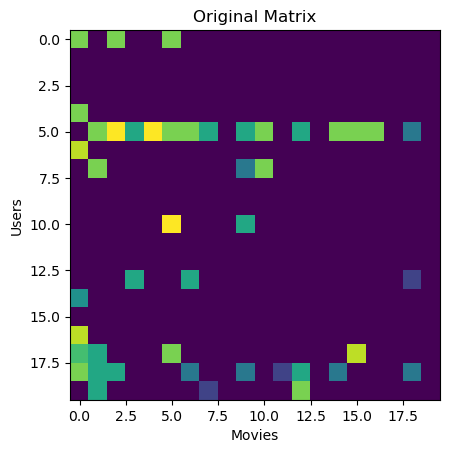

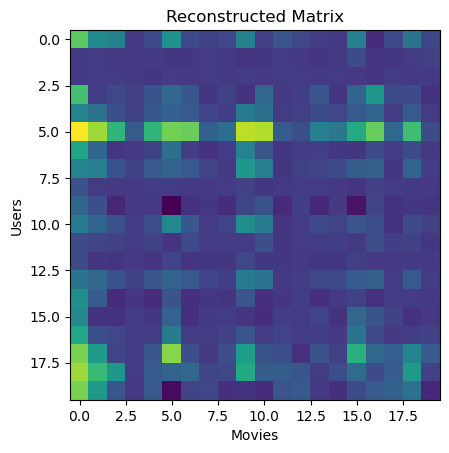

In [6]:
# Visualization 1: Heatmap
plt.imshow(R[:20, :20])
plt.title("Original Matrix")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

plt.imshow(R_pred[:20, :20])
plt.title("Reconstructed Matrix")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()


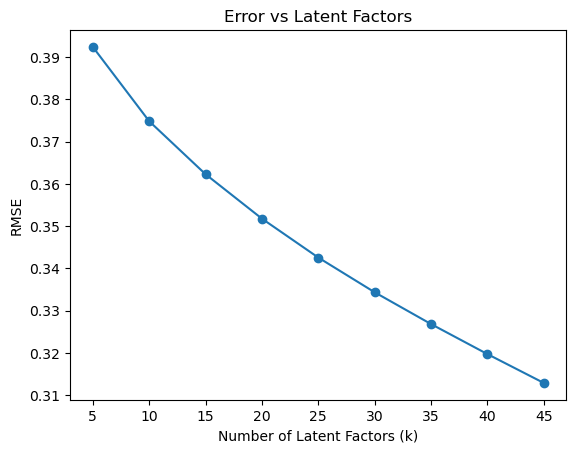

In [7]:
# Visualization 2: Error vs K
errors = []
k_values = range(5, 50, 5)

for k in k_values:
    svd = TruncatedSVD(n_components=k, random_state=42)
    temp = svd.fit_transform(R_centered)
    recon = np.dot(temp, svd.components_) + user_mean.reshape(-1, 1)
    errors.append(np.sqrt(mean_squared_error(R, recon)))

plt.plot(k_values, errors, marker='o')
plt.title("Error vs Latent Factors")
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.show()

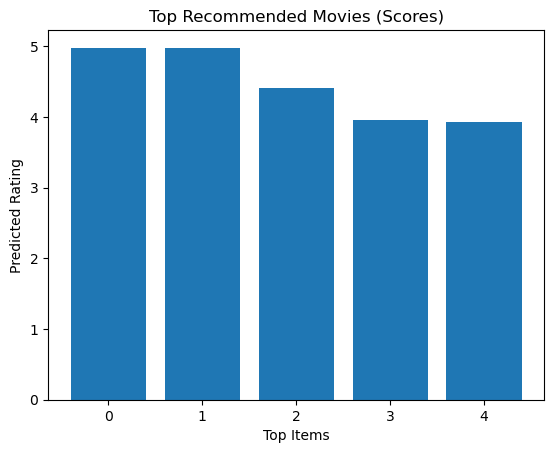

In [8]:
# Visualization 3: Top Recommendations
plt.bar(range(5), user_ratings[top_items])
plt.title("Top Recommended Movies (Scores)")
plt.xlabel("Top Items")
plt.ylabel("Predicted Rating")
plt.show()

SCENARIO 2: NMF RECOMMENDATION

In [9]:
from sklearn.decomposition import NMF

# Load Dataset
df = pd.read_csv("ratings.csv")
print(df.head())

# Create User-Item Matrix
user_item = df.pivot(index='userId', columns='movieId', values='rating')

# Handle missing values (fill with 0)
user_item_filled = user_item.fillna(0)

# Convert to matrix
R = user_item_filled.values


   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [10]:
# Apply NMF
k = 10
nmf = NMF(n_components=k, init='random', random_state=42)
W = nmf.fit_transform(R)   # User-feature matrix
H = nmf.components_        # Item-feature matrix

# Reconstruct Matrix
R_pred = np.dot(W, H)

# Evaluation
rmse = np.sqrt(mean_squared_error(R, R_pred))
print("\nRMSE:", rmse)


RMSE: 0.3808180289983045


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\decomposition\_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [11]:
# Top-N Recommendations
user_id = 1
user_ratings = R_pred[user_id - 1]

top_items = np.argsort(user_ratings)[-5:][::-1]

print("\nTop 5 Recommended Movie IDs (NMF):")
print(top_items)


Top 5 Recommended Movie IDs (NMF):
[897 224 910 899 507]


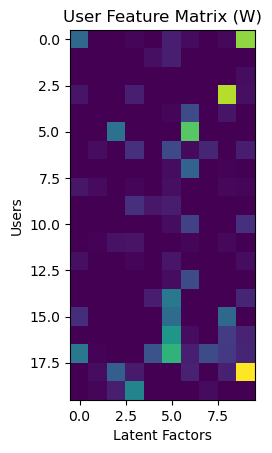

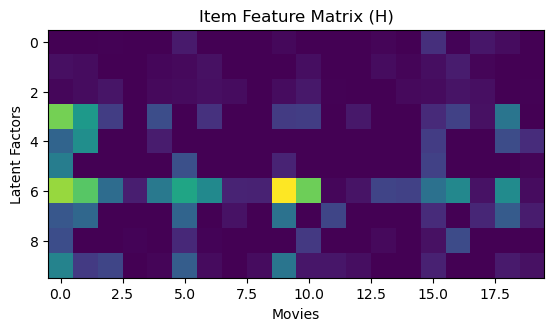

In [12]:
# Visualization 1: Latent Feature Matrices
plt.imshow(W[:20])
plt.title("User Feature Matrix (W)")
plt.xlabel("Latent Factors")
plt.ylabel("Users")
plt.show()

plt.imshow(H[:, :20])
plt.title("Item Feature Matrix (H)")
plt.xlabel("Movies")
plt.ylabel("Latent Factors")
plt.show()

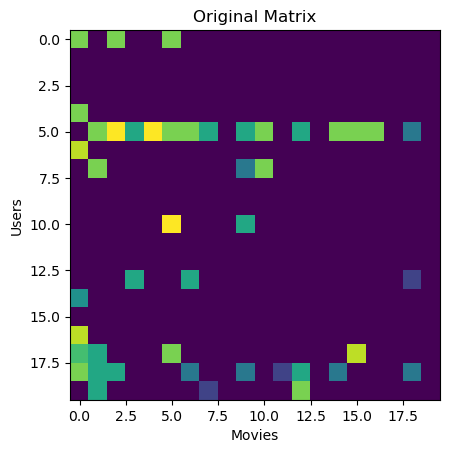

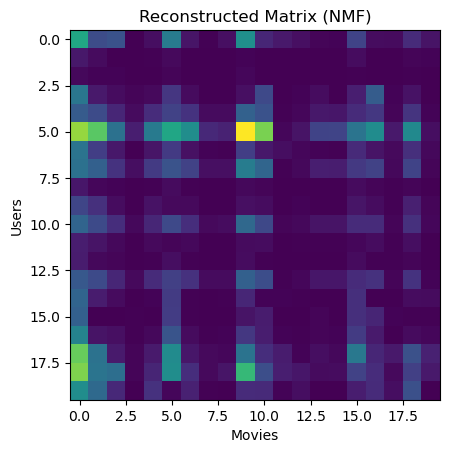

In [13]:
# Visualization 2: Reconstruction Comparison
plt.imshow(R[:20, :20])
plt.title("Original Matrix")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

plt.imshow(R_pred[:20, :20])
plt.title("Reconstructed Matrix (NMF)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

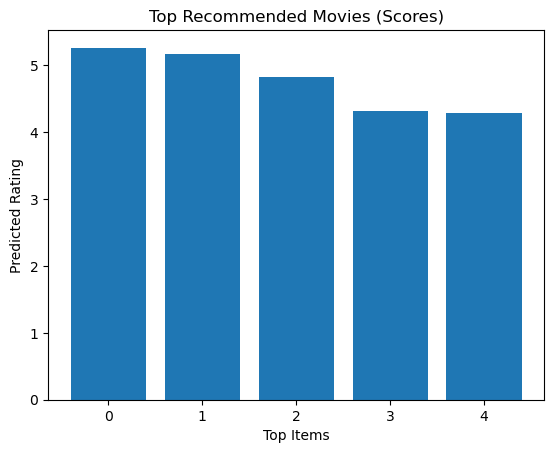

In [14]:
# Visualization 3: Recommendation Ranking
plt.bar(range(5), user_ratings[top_items])
plt.title("Top Recommended Movies (Scores)")
plt.xlabel("Top Items")
plt.ylabel("Predicted Rating")
plt.show()

In [15]:
# Precision@K and Recall@K
def precision_recall_at_k(actual, predicted, k=5):
    actual_set = set(np.where(actual > 0)[0])  # items user rated
    pred_set = set(np.argsort(predicted)[-k:])

    precision = len(actual_set & pred_set) / k
    recall = len(actual_set & pred_set) / len(actual_set) if len(actual_set) > 0 else 0

    return precision, recall

precision, recall = precision_recall_at_k(R[user_id - 1], R_pred[user_id - 1])

print("\nPrecision@5:", precision)
print("Recall@5:", recall)


Precision@5: 0.8
Recall@5: 0.017241379310344827
